<a href="https://colab.research.google.com/github/mendresvon/intro_to_deep_learning_class_notebooks/blob/main/U_NET_Draft_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div><progress max="598913237" value="598917120"></progress> 100.00% [598917120/598913237 00:40&lt;00:00]</div>

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 151MB/s]


epoch,train_loss,valid_loss,acc_camvid,dice_coeff,time
0,11.917970,2.194880,0.253052,0.245322,01:32


epoch,train_loss,valid_loss,acc_camvid,dice_coeff,time
0,1.092873,0.971544,0.776369,0.753043,01:36
1,0.810830,0.664196,0.828611,0.808784,01:35
2,0.622763,0.597727,0.848700,0.827828,01:34


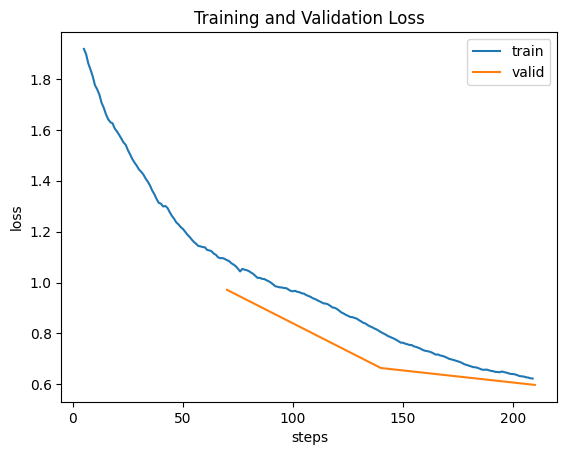

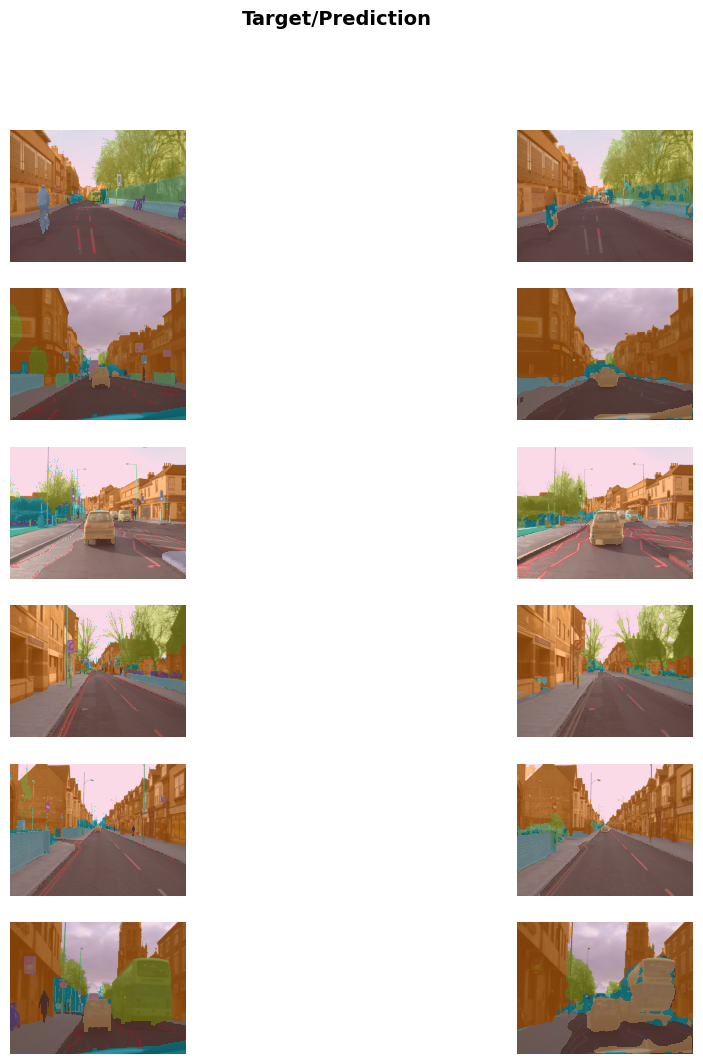

Model exported successfully! Ready for Gradio.


In [1]:
# --- IMPORTS ---
!pip install -Uqq fastai
from fastai.vision.all import *
import numpy as np
import matplotlib.pyplot as plt
import torch

# --- DATA PREPARATION ---
# Downloading the FULL dataset, not the tiny one
path = untar_data(URLs.CAMVID)
path_labels = path/'labels'
path_images = path/'images'

# Load the class codes (Road, Car, Pedestrian, etc.)
codes = np.loadtxt(path/'codes.txt', dtype=str)

# Function to map an image file to its corresponding mask file
def get_mask_path(x):
    return path_labels/f'{x.stem}_P{x.suffix}'

# --- CUSTOM METRICS ---
# CamVid has a 'Void' class (pixels that are unlabeled). We must ignore it for accurate metrics.
name2id = {v:k for k,v in enumerate(codes)}
void_code = name2id.get('Void', 30)

def acc_camvid(inp, targ):
    targ = targ.squeeze(1)
    mask = targ != void_code
    pred = inp.argmax(dim=1)
    return (pred[mask] == targ[mask]).float().mean()

def dice_coeff(inp, targ):
    pred = inp.argmax(dim=1)
    intersection = (pred == targ).float().sum()
    union = pred.numel() + targ.numel()
    return (2. * intersection) / union

# --- DATABLOCK ARCHITECTURE ---
# Explicitly defining the PyTorch data pipeline
camvid_block = DataBlock(
    blocks=(ImageBlock, MaskBlock(codes)),
    get_items=get_image_files,
    get_y=get_mask_path,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize((360, 480)),
    batch_tfms=[
        *aug_transforms(size=(360, 480), max_lighting=0.1, p_lighting=0.5),
        Normalize.from_stats(*imagenet_stats)
    ]
)

# Initialize DataLoaders
dls = camvid_block.dataloaders(path_images, bs=8)

# --- MODEL INITIALIZATION & TRAINING ---
# Using U-Net with ResNet34, adding self-attention for better spatial awareness
learn = unet_learner(
    dls,
    resnet34,
    metrics=[acc_camvid, dice_coeff],
    self_attention=True,
    act_cls=Mish
)

# Train the model (This will take ~30-45 minutes on a free T4 GPU)
learn.fine_tune(3, base_lr=3e-3)

# --- VISUALIZATION & EXPORT ---
# Plot loss curve
learn.recorder.plot_loss()
plt.title('Training and Validation Loss')
plt.show()

# Show the high-quality predictions
learn.show_results(max_n=6, figsize=(12, 12))
plt.show()

# Export the trained model
learn.export('export.pkl')
print("Model exported successfully! Ready for Gradio.")